In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='tab10')
print('Setup complete! All libraries imported.')

Setup complete! All libraries imported.


In [4]:
df = pd.read_csv('owid-covid-data.csv')
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Number of countries: {df["location"].nunique()}')
print('\nColumn names:')
print(df.columns.tolist())

Shape: (350085, 67)
Date range: 2020-01-01 to 2023-10-24
Number of countries: 255

Column names:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinati

In [5]:
cols_needed = [
'iso_code', 'continent', 'location', 'date',
'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
'total_vaccinations', 'people_fully_vaccinated',
'total_cases_per_million', 'total_deaths_per_million',
'new_cases_smoothed', 'new_deaths_smoothed',
'positive_rate', 'gdp_per_capita', 'population',
'human_development_index'
]
df = df[cols_needed].copy()
print(f'Reduced to {df.shape[1]} columns')
df['date'] = pd.to_datetime(df['date'])
exclude = ['World','High income','Low income','Upper middle income',
'Lower middle income','Europe','Asia','Africa',
'North America','South America','Oceania']
df = df[~df['location'].isin(exclude)]
print(f'Country rows only: {len(df):,}')

Reduced to 18 columns
Country rows only: 334,810


In [6]:
print('Missing values per column:')
print(df.isnull().sum().sort_values(ascending=False).head(10))
df = df.sort_values(['location', 'date'])
df[['total_cases','total_deaths','total_vaccinations',
'people_fully_vaccinated']] = df.groupby('location')[
['total_cases','total_deaths','total_vaccinations',
'people_fully_vaccinated']].ffill()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print('\nMissing values after cleaning:')
print(df.isnull().sum().sum())

Missing values per column:
people_fully_vaccinated     273216
total_vaccinations          266646
positive_rate               238883
human_development_index      73062
gdp_per_capita               65337
total_deaths                 59178
total_deaths_per_million     59178
total_cases                  37740
total_cases_per_million      37740
new_cases_smoothed           10792
dtype: int64

Missing values after cleaning:
1390


In [8]:
df['new_cases_7day'] = df.groupby('location')['new_cases'].transform(
lambda x: x.rolling(window=7, min_periods=1).mean())
df['new_deaths_7day'] = df.groupby('location')['new_deaths'].transform(
lambda x: x.rolling(window=7, min_periods=1).mean())
india = df[df['location'] == 'India'][['date','new_cases','new_cases_7day']].tail(5)
print(india.to_string(index=False))

      date  new_cases  new_cases_7day
2023-10-19        0.0       16.428571
2023-10-20        0.0       11.142857
2023-10-21        0.0        3.857143
2023-10-22        0.0        0.000000
2023-10-23        0.0        0.000000


In [9]:
latest = df.sort_values('date').groupby('location').last().reset_index()
top_deaths = latest.nlargest(10, 'total_deaths_per_million')[
['location', 'total_deaths_per_million', 'total_cases_per_million']]
print('Top 10 countries by deaths per million:')
print(top_deaths.to_string(index=False))
latest['vacc_rate'] = (latest['people_fully_vaccinated'] / latest['population']) * 100
top_vacc = latest.nlargest(10, 'vacc_rate')[['location','vacc_rate']]
print('\nTop 10 most vaccinated countries (%):')
print(top_vacc.to_string(index=False))
latest['CFR'] = (latest['total_deaths'] / latest['total_cases'].replace(0, np.nan)) * 100
top_cfr = latest.nlargest(10,'CFR')[['location','CFR','total_cases','total_deaths']]
print('\nTop 10 countries by Case Fatality Rate (%):')
print(top_cfr.to_string(index=False))

Top 10 countries by deaths per million:
              location  total_deaths_per_million  total_cases_per_million
                  Peru                  6511.209               132768.919
Bosnia and Herzegovina                  5058.558               124694.374
               Hungary                  4897.513               221521.186
       North Macedonia                  4750.655               166747.707
               Georgia                  4575.384               495485.640
               Croatia                  4558.897               316537.898
              Slovenia                  4456.934               634662.095
            Montenegro                  4232.301               400713.144
                Latvia                  3989.941               527551.882
              Slovakia                  3750.717               330940.355

Top 10 most vaccinated countries (%):
            location  vacc_rate
           Gibraltar 126.893534
             Tokelau 116.376123
           

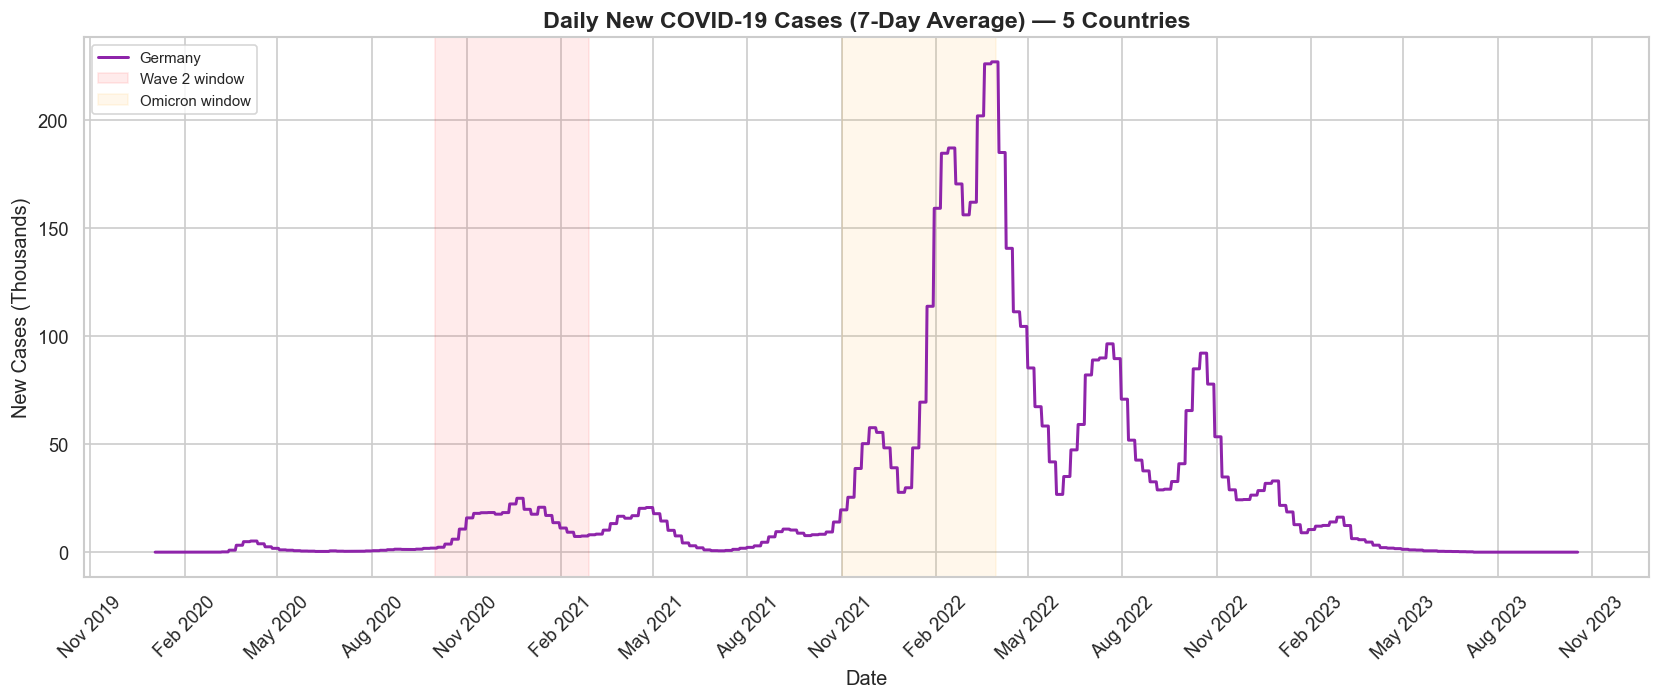

In [11]:
countries = ['India', 'United States', 'United Kingdom', 'Brazil', 'Germany']
colors_map = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA']
fig, ax = plt.subplots(figsize=(14, 6))
for country, color in zip(countries, colors_map):
 data = df[df['location'] == country].copy()
ax.plot(data['date'], data['new_cases_7day'] / 1000,
label=country, color=color, linewidth=1.8)
ax.axvspan(pd.Timestamp('2020-10-01'), pd.Timestamp('2021-02-28'),
alpha=0.08, color='red', label='Wave 2 window')
ax.axvspan(pd.Timestamp('2021-11-01'), pd.Timestamp('2022-03-31'),
alpha=0.08, color='orange', label='Omicron window')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Daily New COVID-19 Cases (7-Day Average) — 5 Countries',
fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('New Cases (Thousands)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_timeseries_cases.png', dpi=150, bbox_inches='tight')
plt.show()


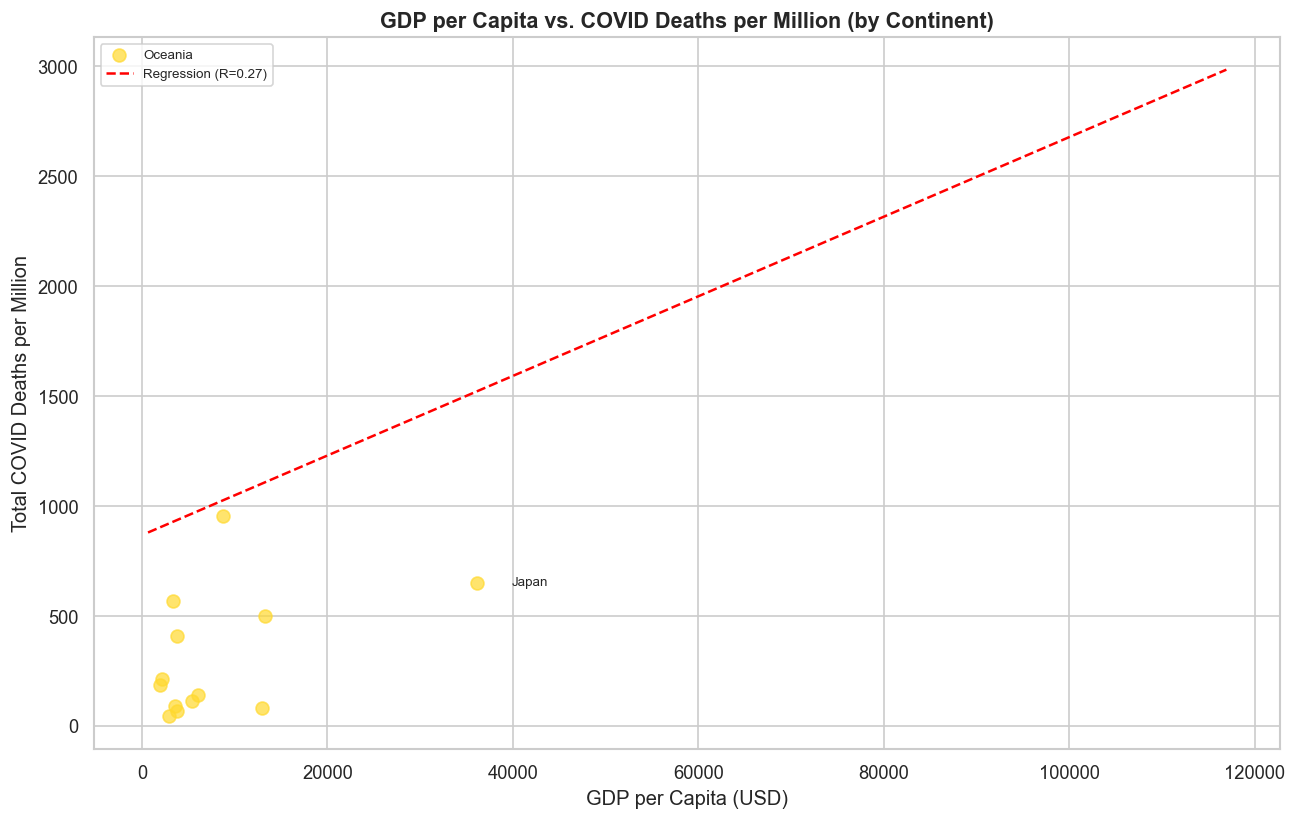

Pearson R = 0.271, p-value = 0.0003
The correlation IS statistically significant (p < 0.05)


In [15]:
scatter_df = latest.dropna(subset=['gdp_per_capita','total_deaths_per_million'])
scatter_df = scatter_df[scatter_df['total_deaths_per_million'] > 0]
scatter_df = scatter_df[scatter_df['gdp_per_capita'] > 0]
fig, ax = plt.subplots(figsize=(11, 7))
continents = scatter_df['continent'].unique()
cont_colors = sns.color_palette('Set2', len(continents))
for cont, col in zip(continents, cont_colors):
 mask = scatter_df['continent'] == cont
ax.scatter(scatter_df[mask]['gdp_per_capita'],
scatter_df[mask]['total_deaths_per_million'],
label=cont, color=col, alpha=0.7, s=60)
slope, intercept, r_value, p_value, std_err = stats.linregress(
scatter_df['gdp_per_capita'],
scatter_df['total_deaths_per_million'])
x_line = np.linspace(scatter_df['gdp_per_capita'].min(),
scatter_df['gdp_per_capita'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='red',
linewidth=1.5, label=f'Regression (R={r_value:.2f})')
for _, row in scatter_df[scatter_df['location'].isin(
['India','United States','Peru','Japan'])].iterrows():
 ax.annotate(row['location'],
(row['gdp_per_capita'], row['total_deaths_per_million']),
fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_title('GDP per Capita vs. COVID Deaths per Million (by Continent)',
fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Total COVID Deaths per Million')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('chart2_gdp_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson R = {r_value:.3f}, p-value = {p_value:.4f}')
if p_value < 0.05:
 print('The correlation IS statistically significant (p < 0.05)')

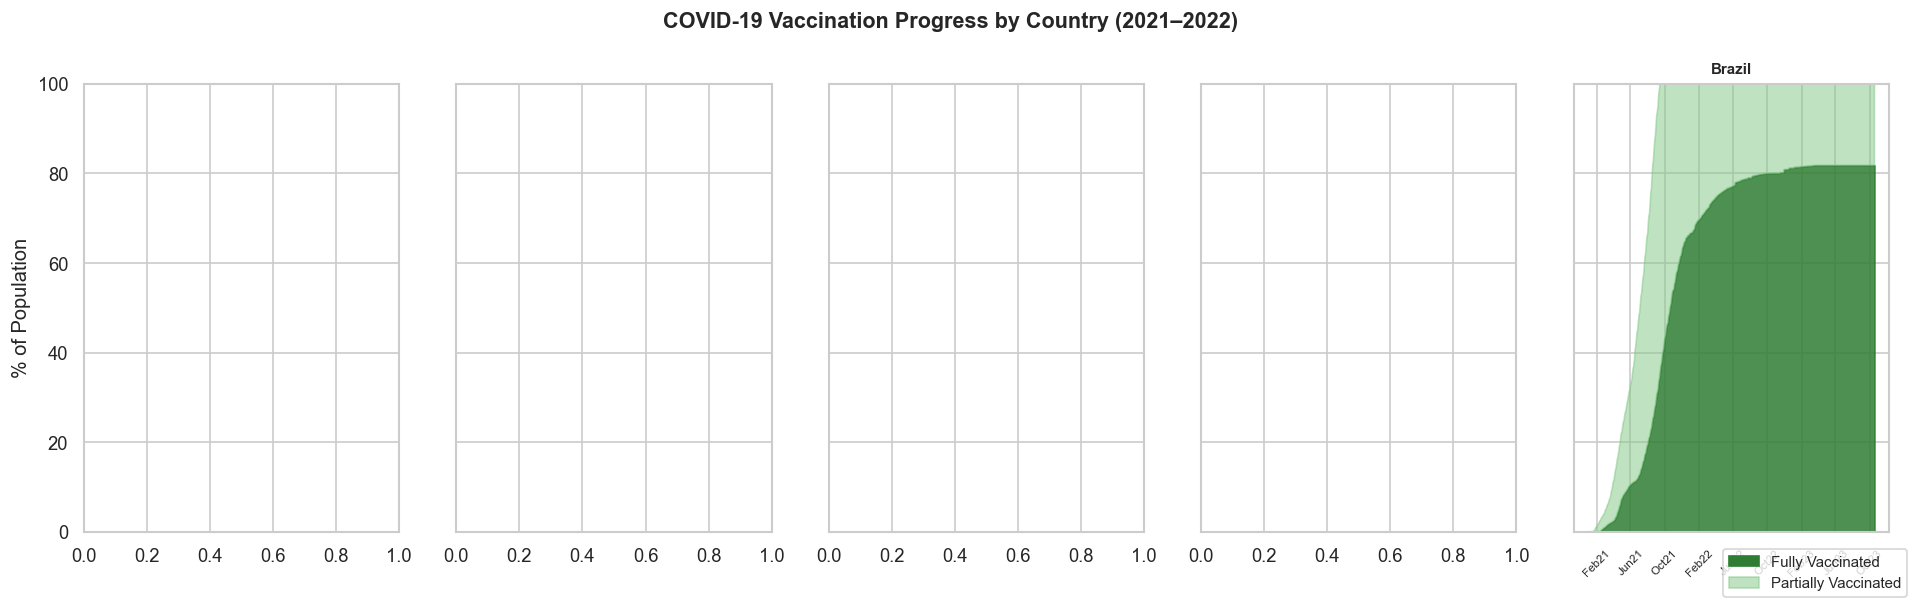

In [17]:
vacc_countries = ['United States', 'United Kingdom', 'India', 'Germany', 'Brazil']
fig, axes = plt.subplots(1, len(vacc_countries), figsize=(16, 5), sharey=True)
for ax, country in zip(axes, vacc_countries):
 data = df[df['location'] == country].copy()
data = data[data['date'] >= '2021-01-01'] # Vaccines started ~Jan 2021
data['vacc_pct'] = (data['people_fully_vaccinated'] / data['population']) * 100
data['partial_pct'] = ((data['total_vaccinations'] - data['people_fully_vaccinated'])
/ data['population']) * 100
ax.fill_between(data['date'], data['vacc_pct'],
alpha=0.85, color='#2E7D32', label='Fully Vaccinated')
ax.fill_between(data['date'], data['vacc_pct'],
data['vacc_pct'] + data['partial_pct'].clip(lower=0),
alpha=0.5, color='#81C784', label='Partially Vaccinated')
ax.set_title(country, fontsize=9, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)
ax.set_ylim(0, 100)
axes[0].set_ylabel('% of Population')
fig.suptitle('COVID-19 Vaccination Progress by Country (2021–2022)',
fontsize=13, fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color='#2E7D32'),
plt.Rectangle((0,0),1,1, color='#81C784', alpha=0.5)]
fig.legend(handles, ['Fully Vaccinated','Partially Vaccinated'],
loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_vaccination_progress.png', dpi=150, bbox_inches='tight')
plt.show()

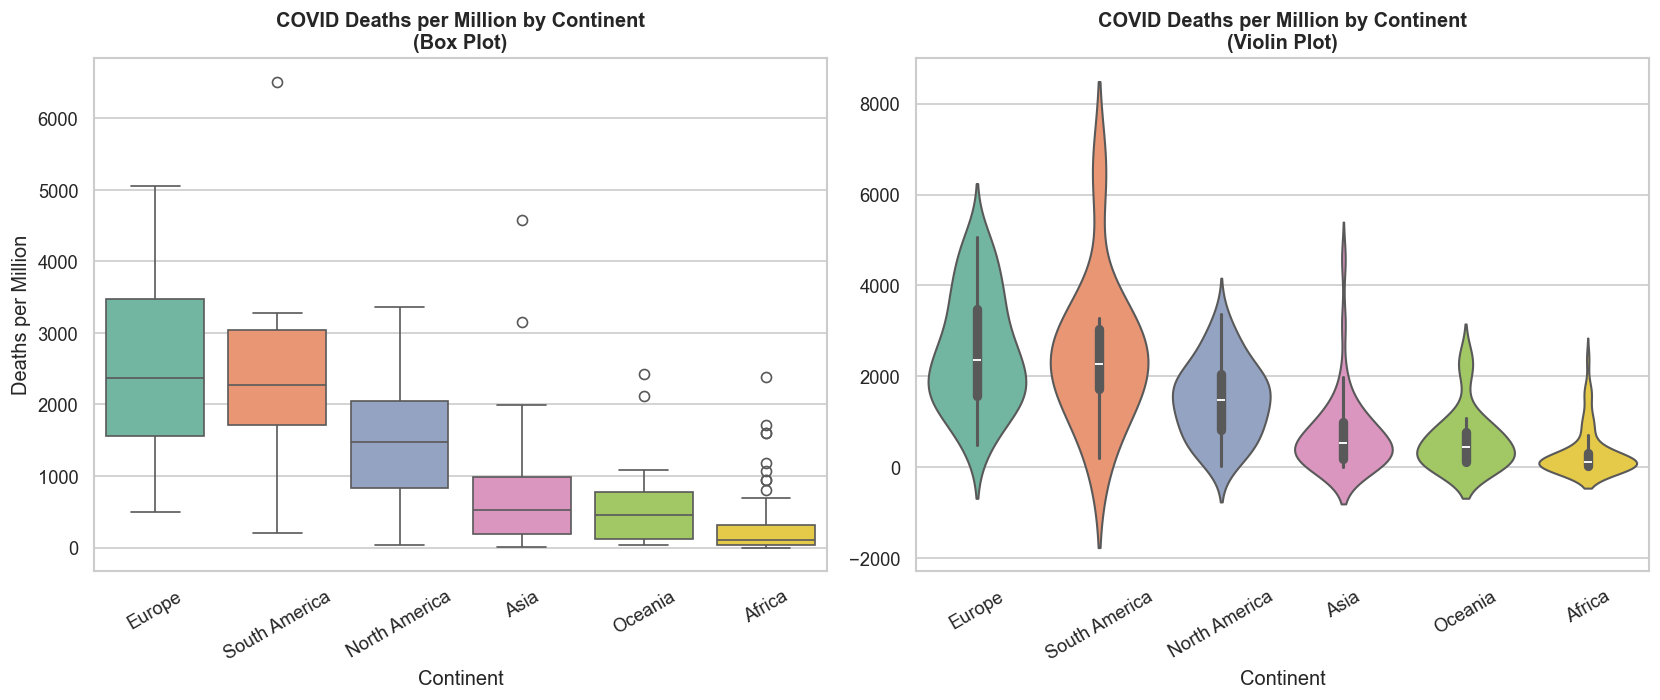

In [19]:
cont_df = latest.dropna(subset=['continent','total_deaths_per_million'])
cont_df = cont_df[cont_df['total_deaths_per_million'] > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = cont_df.groupby('continent')['total_deaths_per_million'].median().sort_values(ascending=False).index
sns.boxplot(data=cont_df, x='continent', y='total_deaths_per_million',
order=order, palette='Set2', ax=axes[0])
axes[0].set_title('COVID Deaths per Million by Continent\n(Box Plot)', fontsize=12,
fontweight='bold')
axes[0].set_xlabel('Continent')
axes[0].set_ylabel('Deaths per Million')
axes[0].tick_params(axis='x', rotation=30)
sns.violinplot(data=cont_df, x='continent', y='total_deaths_per_million',
order=order, palette='Set2', ax=axes[1], inner='box')
axes[1].set_title('COVID Deaths per Million by Continent\n(Violin Plot)', fontsize=12,
fontweight='bold')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('chart4_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()

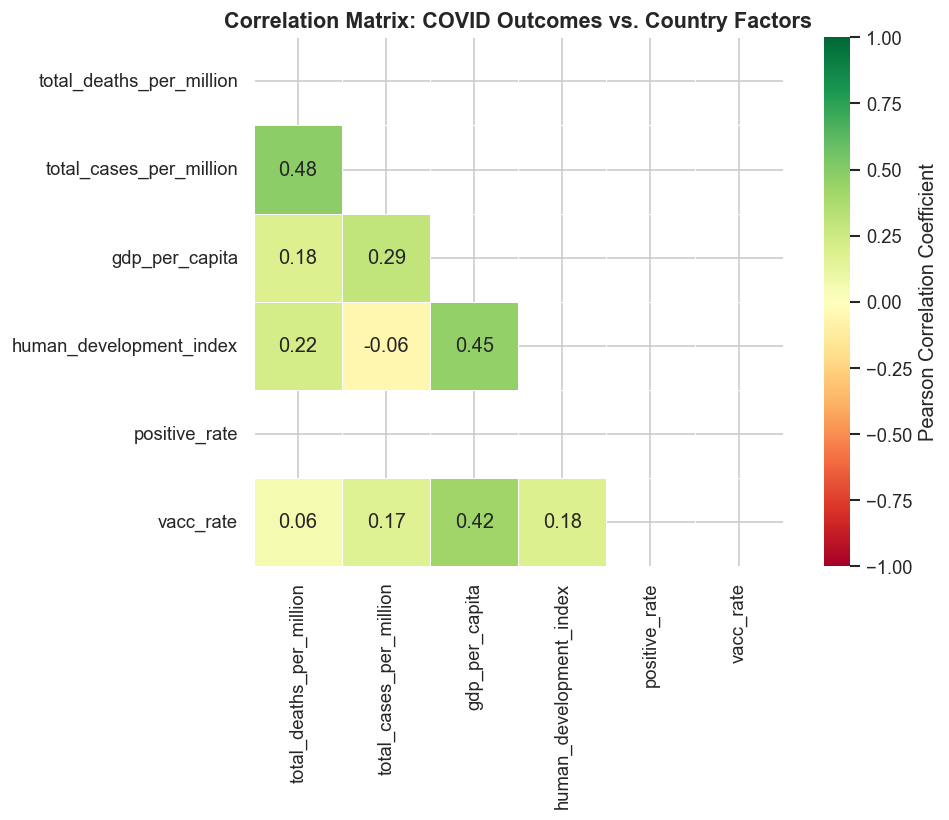


Top correlations with deaths per million:
total_deaths_per_million    1.000000
total_cases_per_million     0.483552
human_development_index     0.218310
gdp_per_capita              0.180806
vacc_rate                   0.060322
positive_rate                    NaN
Name: total_deaths_per_million, dtype: float64


In [20]:
corr_cols = ['total_deaths_per_million', 'total_cases_per_million',
'gdp_per_capita', 'human_development_index',
'positive_rate', 'vacc_rate']
corr_df = latest[corr_cols].dropna()
corr_matrix = corr_df.corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # hide upper triangle
sns.heatmap(corr_matrix,
mask=mask,
annot=True,
fmt='.2f',
cmap='RdYlGn',
vmin=-1, vmax=1,
linewidths=0.5,
square=True,
cbar_kws={'label': 'Pearson Correlation Coefficient'})
plt.title('Correlation Matrix: COVID Outcomes vs. Country Factors',
fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop correlations with deaths per million:')
print(corr_matrix['total_deaths_per_million'].sort_values(ascending=False))            

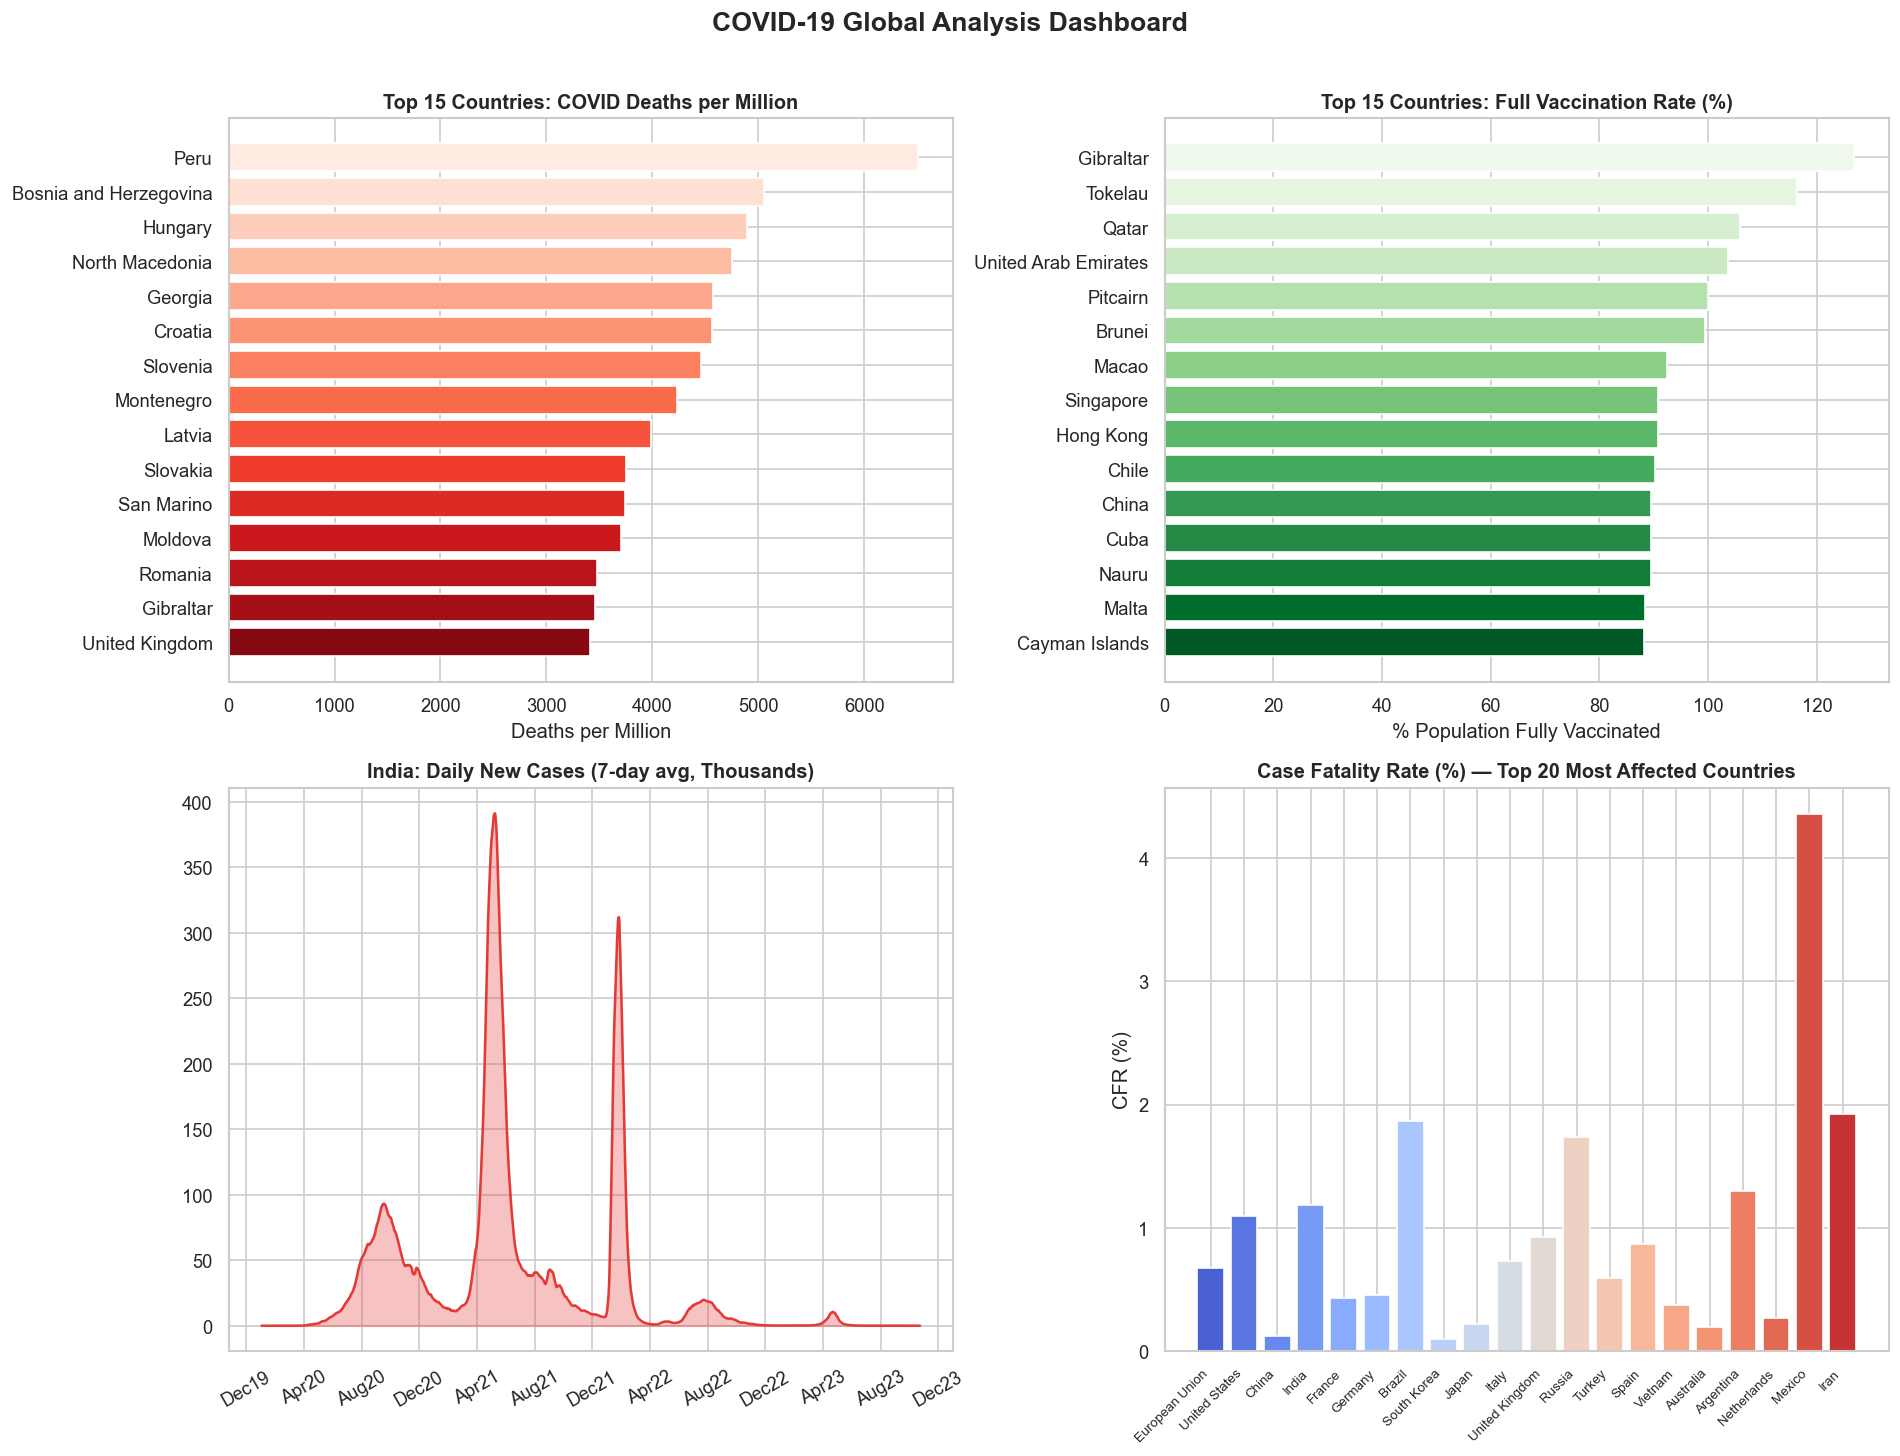

In [21]:
top15 = latest.nlargest(15, 'total_deaths_per_million')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0,0].barh(top15['location'][::-1], top15['total_deaths_per_million'][::-1],
color=sns.color_palette('Reds_r', 15))
axes[0,0].set_title('Top 15 Countries: COVID Deaths per Million', fontweight='bold')
axes[0,0].set_xlabel('Deaths per Million')
top15_vacc = latest.nlargest(15, 'vacc_rate')
axes[0,1].barh(top15_vacc['location'][::-1], top15_vacc['vacc_rate'][::-1],
color=sns.color_palette('Greens_r', 15))
axes[0,1].set_title('Top 15 Countries: Full Vaccination Rate (%)', fontweight='bold')
axes[0,1].set_xlabel('% Population Fully Vaccinated')
india_data = df[df['location']=='India']
axes[1,0].plot(india_data['date'], india_data['new_cases_7day']/1000,
color='#E53935', linewidth=1.5)
axes[1,0].fill_between(india_data['date'],
india_data['new_cases_7day']/1000, alpha=0.3, color='#E53935')
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
axes[1,0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[1,0].get_xticklabels(), rotation=30)
axes[1,0].set_title('India: Daily New Cases (7-day avg, Thousands)', fontweight='bold')
top20_cases = latest.nlargest(20,'total_cases')
axes[1,1].bar(range(len(top20_cases)), top20_cases['CFR'],
color=sns.color_palette('coolwarm', 20))
axes[1,1].set_xticks(range(len(top20_cases)))
axes[1,1].set_xticklabels(top20_cases['location'], rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('Case Fatality Rate (%) — Top 20 Most Affected Countries',
fontweight='bold')
axes[1,1].set_ylabel('CFR (%)')
fig.suptitle('COVID-19 Global Analysis Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
